# EDA 03 — Core Stack per Role (Required-Rate Matrix)

**Câu hỏi**: Với mỗi role, skill nào là **core** (>60% JD yêu cầu) vs **nice-to-have** (<30%)?

**Cách làm**: Pivot table `standardized_title × skill_name`, ô = % JD trong role đó có skill X được mark `required_skill`.  
Filter: role có ≥20 records, skill xuất hiện trong ≥10 JD.  
Viz: Heatmap — cột = role, hàng = top 30 skills, màu = required-rate, annotate ô >80%.

**Input**: `data/processed/skills.parquet`, `data/processed/jobs_cleaned.parquet`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 10
sns.set_theme(style='white')

DATA_DIR = Path('../data/processed')

## 1. Load & chuẩn bị dữ liệu

In [2]:
skills = pd.read_parquet(DATA_DIR / 'skills.parquet')
jobs   = pd.read_parquet(DATA_DIR / 'jobs_cleaned.parquet')[['job_id', 'standardized_title']]

# Chỉ giữ 2 label hợp lệ
skills = skills[skills['label'].isin(['required_skill', 'preferred_skill'])].copy()

# Canonical skill: dùng final_canonical, fallback về skill_name lowercase
skills['canonical'] = skills['final_canonical'].fillna(
    skills['skill_name'].str.lower().str.strip()
)

# Merge để lấy standardized_title
df = skills.merge(jobs, on='job_id', how='inner')

print(f"Skill mentions after merge : {len(df):,}")
print(f"Unique jobs                : {df['job_id'].nunique():,}")
print(f"Unique roles               : {df['standardized_title'].nunique():,}")
print(f"Unique canonical skills    : {df['canonical'].nunique():,}")

Skill mentions after merge : 56,335
Unique jobs                : 3,168
Unique roles               : 147
Unique canonical skills    : 2,762


## 2. Xây dựng Required-Rate Matrix

**Required-rate(role, skill)** = số JD trong role có skill X được mark `required_skill` / tổng số JD trong role đó.

- Nếu 1 JD có cùng 1 skill với 2 label khác nhau → ưu tiên `required_skill` (conservative).
- Filter: role ≥20 JD, skill xuất hiện trong ≥10 JD.

In [3]:
MIN_ROLE_JDS  = 20   # role phải có ít nhất 20 JD
MIN_SKILL_JDS = 10   # skill phải xuất hiện trong ít nhất 10 JD (toàn dataset)
TOP_N_SKILLS  = 30   # hiển thị top 30 skills trên heatmap

# --- Bước 1: per (job_id, canonical) → is_required ---
# Nếu skill xuất hiện nhiều lần trong cùng 1 JD, lấy max (required > preferred)
job_skill = (
    df.groupby(['job_id', 'canonical', 'standardized_title'], as_index=False)
    .agg(is_required=('label', lambda x: int('required_skill' in x.values)))
)

# --- Bước 2: lọc roles đủ lớn ---
role_jd_counts = jobs['standardized_title'].value_counts()
valid_roles = role_jd_counts[role_jd_counts >= MIN_ROLE_JDS].index
job_skill = job_skill[job_skill['standardized_title'].isin(valid_roles)]

# --- Bước 3: lọc skills xuất hiện đủ nhiều ---
skill_jd_counts = job_skill.groupby('canonical')['job_id'].nunique()
valid_skills = skill_jd_counts[skill_jd_counts >= MIN_SKILL_JDS].index
job_skill = job_skill[job_skill['canonical'].isin(valid_skills)]

print(f"Valid roles  (≥{MIN_ROLE_JDS} JDs) : {len(valid_roles):,}")
print(f"Valid skills (≥{MIN_SKILL_JDS} JDs) : {len(valid_skills):,}")

Valid roles  (≥20 JDs) : 29
Valid skills (≥10 JDs) : 772


In [4]:
# --- Bước 4: Required-rate = n_required_jds / total_jds_in_role ---
pivot_raw = (
    job_skill
    .groupby(['standardized_title', 'canonical'])
    .agg(
        n_required_jds = ('is_required', 'sum'),
        n_skill_jds    = ('job_id', 'nunique'),
    )
    .reset_index()
)

# Map total JD per role để tính rate
role_total = role_jd_counts.rename('total_jds')
pivot_raw = pivot_raw.merge(role_total, on='standardized_title')
pivot_raw['required_rate'] = pivot_raw['n_required_jds'] / pivot_raw['total_jds']

# --- Bước 5: Chọn top N skills theo tổng n_skill_jds ---
top_skills = (
    pivot_raw.groupby('canonical')['n_skill_jds'].sum()
    .nlargest(TOP_N_SKILLS)
    .index.tolist()
)

pivot_filtered = pivot_raw[pivot_raw['canonical'].isin(top_skills)]

# Tạo pivot table (role = columns, skill = rows)
heatmap_data = pivot_filtered.pivot_table(
    index='canonical',
    columns='standardized_title',
    values='required_rate',
    aggfunc='mean'
)

# Sắp xếp: cột = role theo số JD giảm dần, hàng = skill theo required_rate trung bình giảm dần
col_order = [r for r in role_jd_counts.index if r in heatmap_data.columns]
row_order = heatmap_data.mean(axis=1, skipna=True).sort_values(ascending=False).index

heatmap_data = heatmap_data.loc[row_order, col_order]

print(f"Heatmap shape: {heatmap_data.shape}  (skills × roles)")
heatmap_data.iloc[:5, :5].round(2)

Heatmap shape: (30, 29)  (skills × roles)


standardized_title,Backend Developer,Business Analyst,QA Engineer,Fullstack Developer,IT Support
canonical,,,,,
communication,0.19,0.67,0.44,0.20,0.42
english,0.33,0.28,0.25,0.37,0.17
teamwork,0.27,0.34,0.35,0.32,0.29
problem solving,0.30,0.28,0.19,0.31,0.19
python,0.14,0.01,0.04,0.20,0.02


## 3. Heatmap — Core Stack per Role

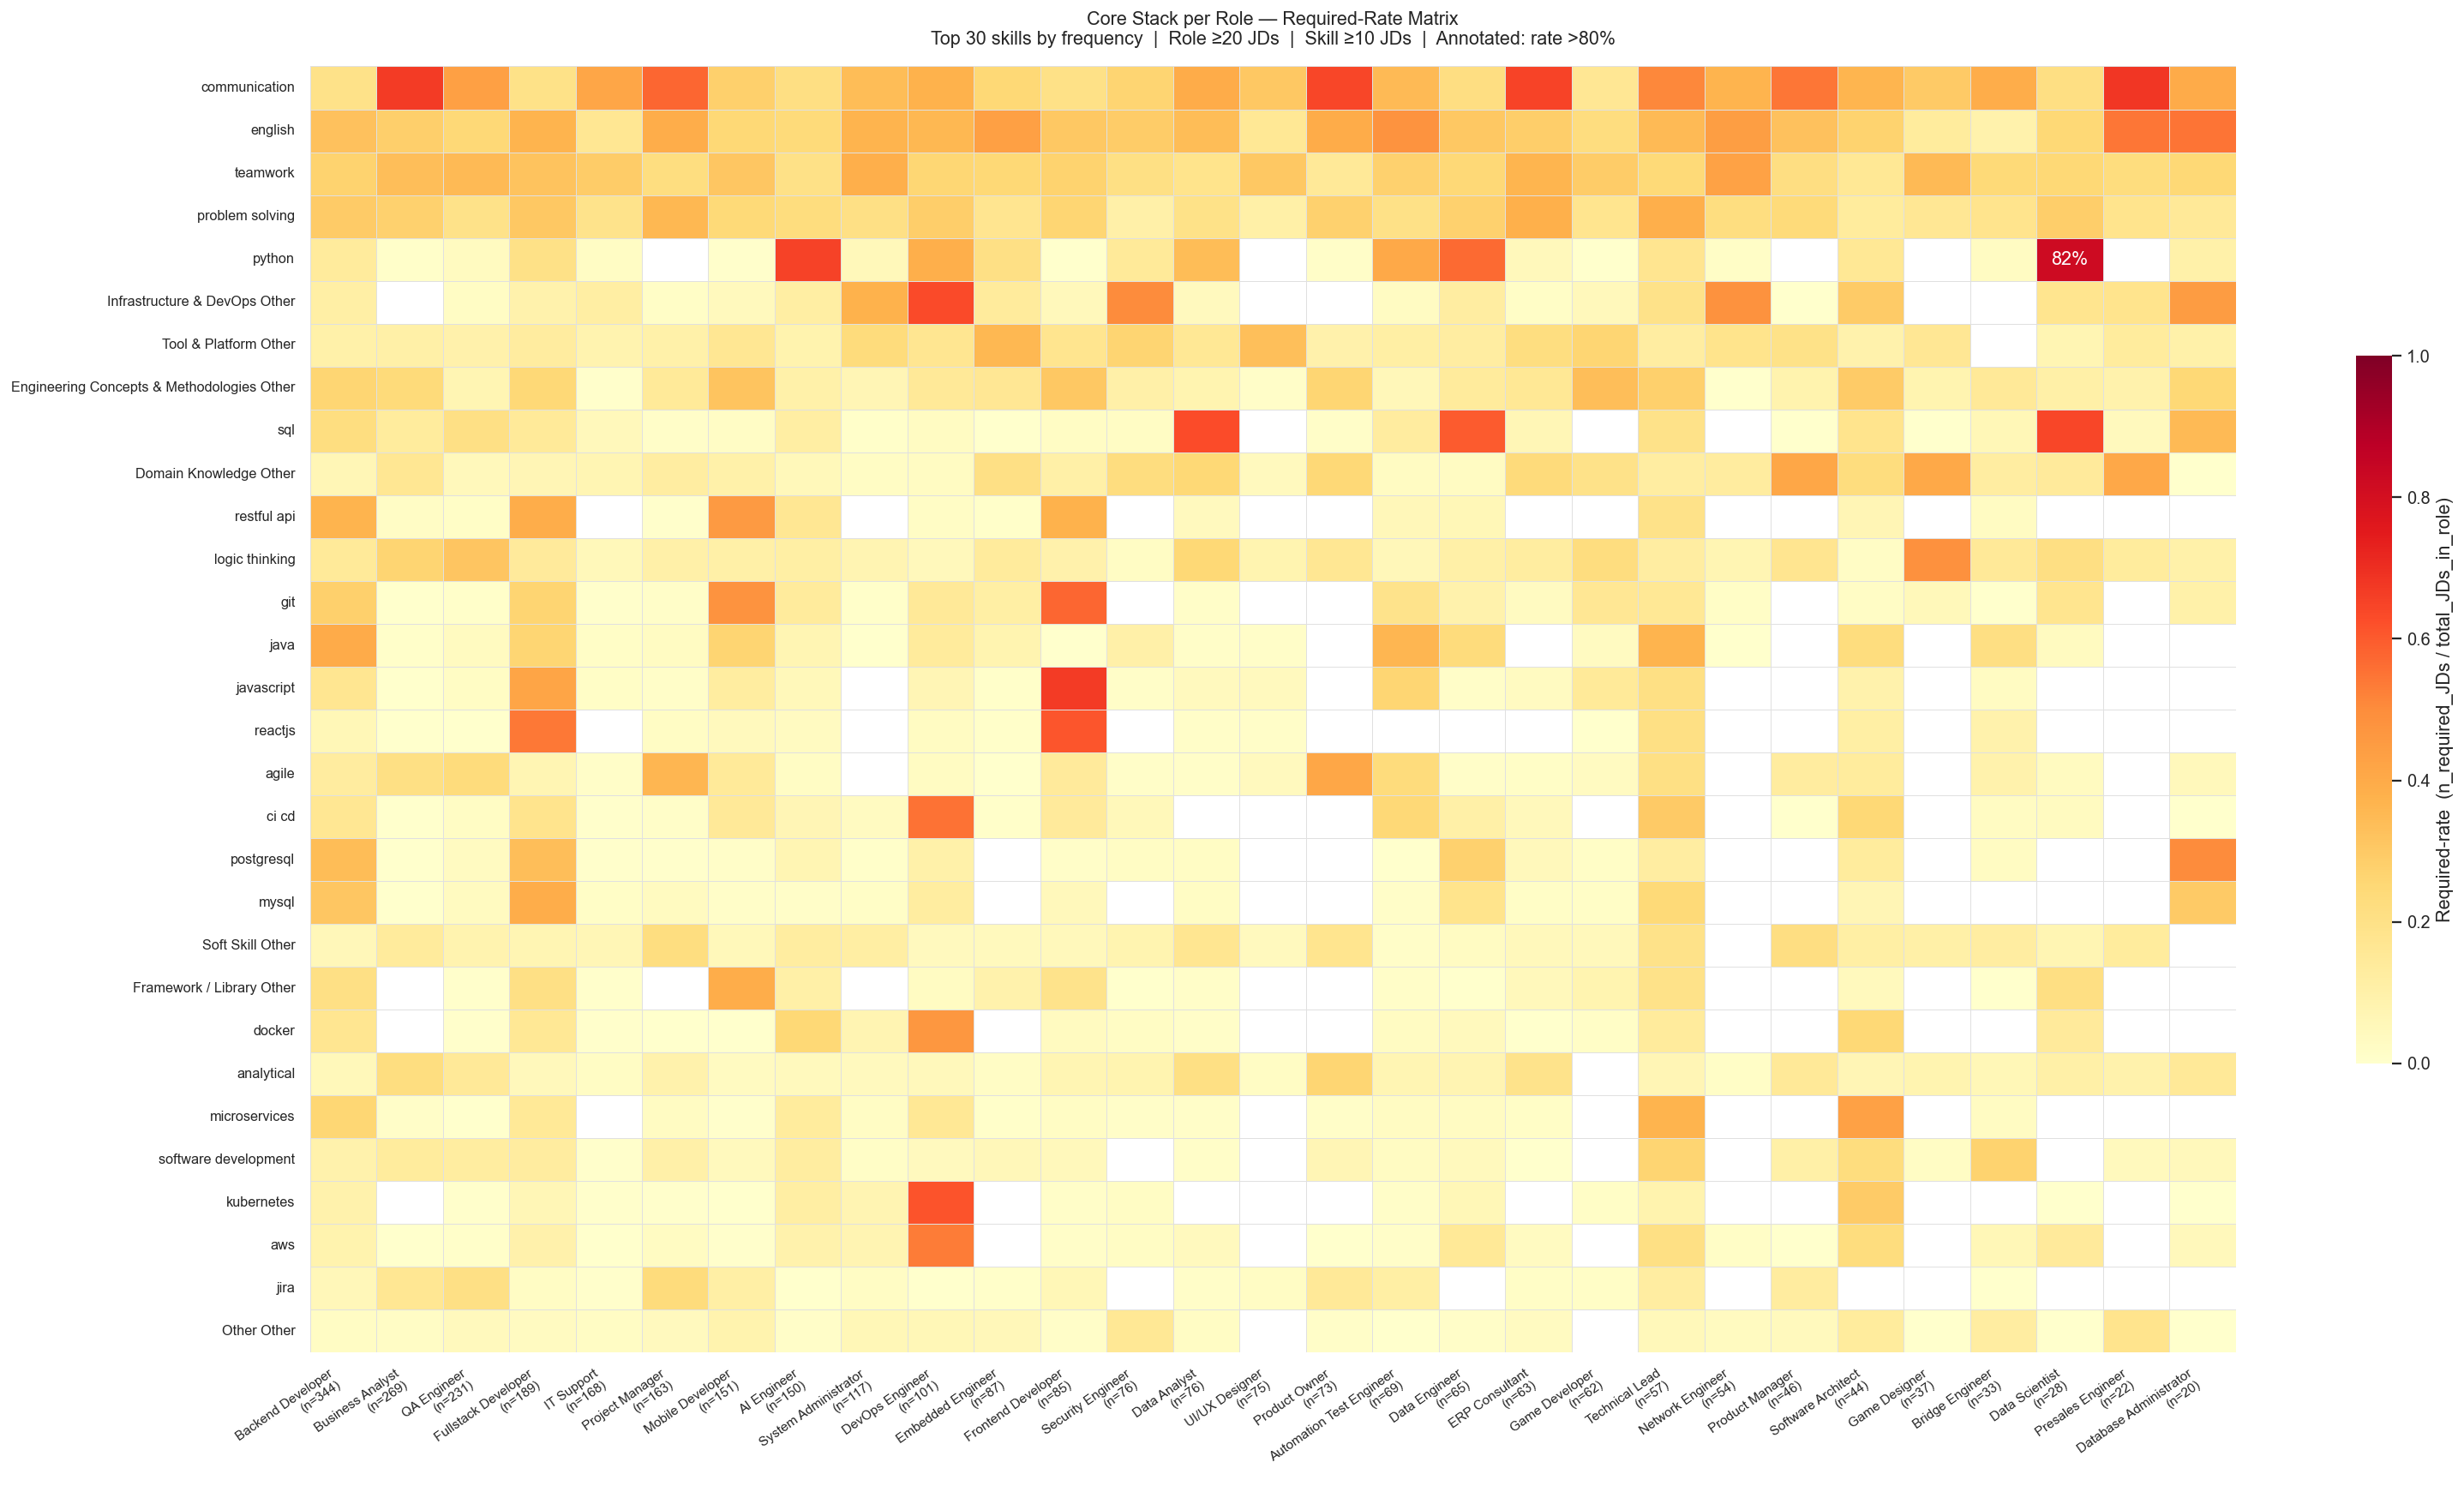

In [ ]:
ANNOTATE_THRESHOLD = 0.80  # annotate cell có required_rate > 80%

n_rows, n_cols = heatmap_data.shape
fig_w = max(14, n_cols * 0.85)
fig_h = max(10, n_rows * 0.45)

fig, ax = plt.subplots(figsize=(fig_w, fig_h))

# Annotation: hiển thị số nếu >80%, ô NaN để trống
annot_str = heatmap_data.map(
    lambda v: f"{v:.0%}" if pd.notna(v) and v > ANNOTATE_THRESHOLD else ""
)

sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    vmin=0, vmax=1,
    annot=annot_str,
    fmt='',
    linewidths=0.3,
    linecolor='#e0e0e0',
    cbar_kws={'label': 'Required-rate  (n_required_JDs / total_JDs_in_role)', 'shrink': 0.55},
    mask=heatmap_data.isna(),
    ax=ax,
)

# Thêm role JD count vào tên cột
new_xlabels = [
    f"{role}\n(n={role_jd_counts[role]})"
    for role in heatmap_data.columns
]
ax.set_xticklabels(new_xlabels, rotation=35, ha='right', fontsize=8.5)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)
ax.set_xlabel('')
ax.set_ylabel('')

ax.set_title(
    f'Core Stack per Role — Required-Rate Matrix\n'
    f'Top {TOP_N_SKILLS} skills by frequency  |  Role ≥{MIN_ROLE_JDS} JDs  |  Skill ≥{MIN_SKILL_JDS} JDs  |  Annotated: rate >{ANNOTATE_THRESHOLD:.0%}',
    fontsize=12, pad=14
)

plt.tight_layout()
plt.savefig('../EDA/figures/EDA_03_core_stack_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

## 4. Core vs Nice-to-Have per Role

**Core** = required-rate >60%  |  **Nice-to-have** = required-rate <30%

In [6]:
CORE_THRESHOLD = 0.60
NTH_THRESHOLD  = 0.30

summary_rows = []
for role in col_order:
    if role not in heatmap_data.columns:
        continue
    col = heatmap_data[role].dropna()
    core = col[col >= CORE_THRESHOLD].sort_values(ascending=False)
    nth  = col[col <= NTH_THRESHOLD].sort_values()
    summary_rows.append({
        'role'          : role,
        'n_jds'         : role_jd_counts[role],
        'core_skills'   : ', '.join(core.index.tolist()),
        'n_core'        : len(core),
        'nth_skills'    : ', '.join(nth.index.tolist()),
        'n_nth'         : len(nth),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('n_jds', ascending=False)
pd.set_option('display.max_colwidth', 120)
display(summary_df[['role', 'n_jds', 'n_core', 'core_skills']].reset_index(drop=True))

,role,n_jds,n_core,core_skills
0,Backend Developer,344,0,
1,Business Analyst,269,1,communication
2,QA Engineer,231,0,
3,Fullstack Developer,189,0,
4,IT Support,168,0,
5,Project Manager,163,0,
6,Mobile Developer,151,0,
7,AI Engineer,150,1,python
8,System Administrator,117,0,
9,DevOps Engineer,101,2,"Infrastructure & DevOps Other, kubernetes"


In [7]:
# In chi tiết từng role
for _, row in summary_df.iterrows():
    print(f"\n{'='*60}")
    print(f"  {row['role']:30s}  (n={row['n_jds']} JDs)")
    print(f"{'='*60}")
    print(f"  CORE (>{CORE_THRESHOLD:.0%})  [{row['n_core']} skills]:")
    if row['core_skills']:
        for sk in row['core_skills'].split(', '):
            rate = heatmap_data.loc[sk, row['role']] if sk in heatmap_data.index else None
            print(f"    • {sk:<35s}  {rate:.0%}" if rate is not None else f"    • {sk}")
    else:
        print("    (none in top-30 skills)")
    print(f"  NICE-TO-HAVE (<{NTH_THRESHOLD:.0%})  [{row['n_nth']} skills]:")
    if row['nth_skills']:
        for sk in row['nth_skills'].split(', ')[:8]:
            rate = heatmap_data.loc[sk, row['role']] if sk in heatmap_data.index else None
            print(f"    • {sk:<35s}  {rate:.0%}" if rate is not None else f"    • {sk}")
    else:
        print("    (none in top-30 skills)")


  Backend Developer               (n=344 JDs)
  CORE (>60%)  [0 skills]:
    (none in top-30 skills)
  NICE-TO-HAVE (<30%)  [25 skills]:
    • Other Other                          3%
    • analytical                           5%
    • jira                                 6%
    • Soft Skill Other                     6%
    • reactjs                              6%
    • Domain Knowledge Other               6%
    • aws                                  9%
    • software development                 9%

  Business Analyst                (n=269 JDs)
  CORE (>60%)  [1 skills]:
    • communication                        67%
  NICE-TO-HAVE (<30%)  [24 skills]:
    • postgresql                           0%
    • javascript                           0%
    • aws                                  0%
    • git                                  0%
    • ci cd                                0%
    • reactjs                              0%
    • mysql                                0%
    • python   

## 5. Focused Heatmap — Top 8 Roles × Top 20 Skills

Zoom-in vào 8 roles lớn nhất để dễ đọc hơn.

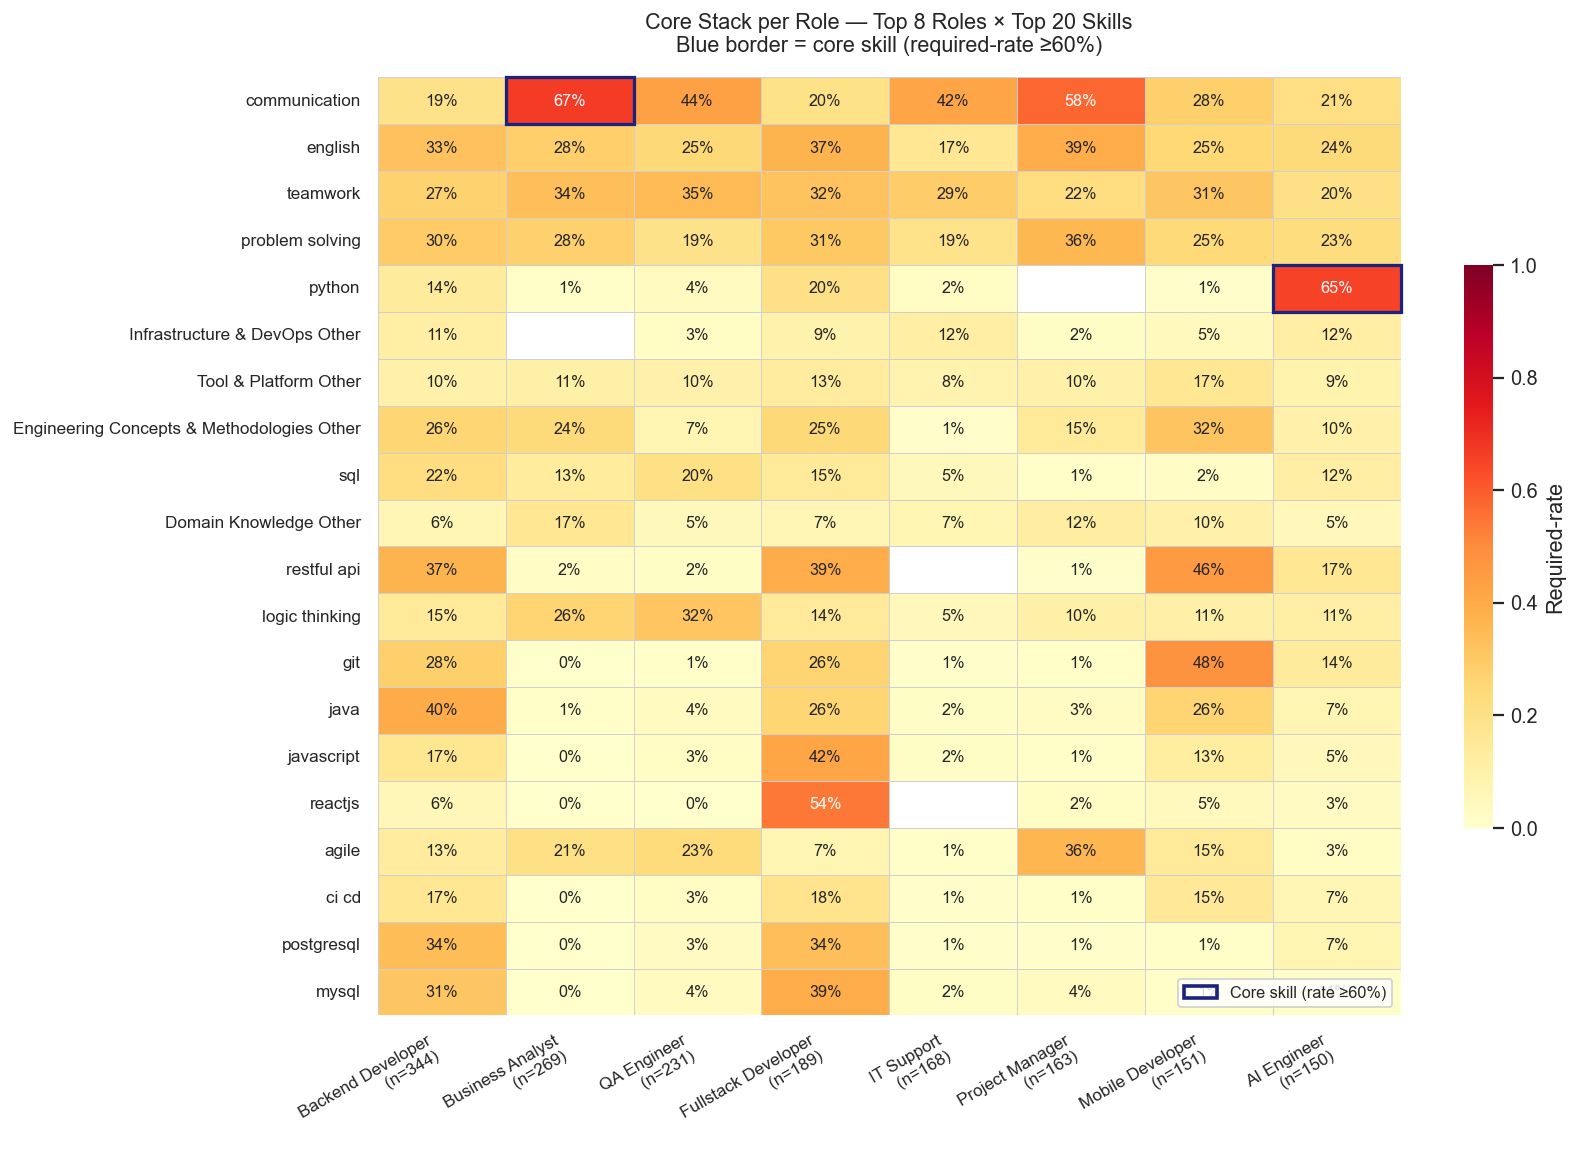

In [8]:
TOP_ROLES  = 8
TOP_SKILLS = 20

focus_roles  = col_order[:TOP_ROLES]
focus_skills = row_order[:TOP_SKILLS]
focus_data   = heatmap_data.loc[focus_skills, focus_roles]

# Annotation: hiển thị tất cả ô có giá trị
focus_annot = focus_data.map(
    lambda v: f"{v:.0%}" if pd.notna(v) else ""
)

fig, ax = plt.subplots(figsize=(13, 9))

sns.heatmap(
    focus_data,
    cmap='YlOrRd',
    vmin=0, vmax=1,
    annot=focus_annot,
    fmt='',
    linewidths=0.5,
    linecolor='#d0d0d0',
    annot_kws={'size': 9},
    cbar_kws={'label': 'Required-rate', 'shrink': 0.6},
    mask=focus_data.isna(),
    ax=ax,
)

new_xlabels = [
    f"{role}\n(n={role_jd_counts[role]})"
    for role in focus_roles
]
ax.set_xticklabels(new_xlabels, rotation=30, ha='right', fontsize=9.5)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9.5)
ax.set_xlabel('')
ax.set_ylabel('')

# Vẽ đường phân cách core (>60%) bằng rectangle annotation
for row_idx, skill in enumerate(focus_skills):
    for col_idx, role in enumerate(focus_roles):
        val = focus_data.loc[skill, role]
        if pd.notna(val) and val >= CORE_THRESHOLD:
            ax.add_patch(plt.Rectangle(
                (col_idx, row_idx), 1, 1,
                fill=False, edgecolor='#1a237e', linewidth=1.8, clip_on=False
            ))

# Legend: blue border = core
core_patch = mpatches.Patch(facecolor='none', edgecolor='#1a237e', linewidth=2, label=f'Core skill (rate ≥{CORE_THRESHOLD:.0%})')
ax.legend(handles=[core_patch], loc='lower right', fontsize=9, framealpha=0.85)

ax.set_title(
    f'Core Stack per Role — Top {TOP_ROLES} Roles × Top {TOP_SKILLS} Skills\n'
    f'Blue border = core skill (required-rate ≥{CORE_THRESHOLD:.0%})',
    fontsize=12, pad=14
)

plt.tight_layout()
plt.savefig('../EDA/figures/EDA_03_core_stack_focused.png', bbox_inches='tight', dpi=150)
plt.show()

## 6. Export summary table

In [9]:
# Long-format table: (role, skill, required_rate, is_core, is_nth)
long_table = pivot_raw[pivot_raw['canonical'].isin(top_skills)].copy()
long_table['is_core'] = long_table['required_rate'] >= CORE_THRESHOLD
long_table['is_nth']  = long_table['required_rate'] <= NTH_THRESHOLD
long_table = long_table.sort_values(['standardized_title', 'required_rate'], ascending=[True, False])

out_path = Path('../data/processed/core_stack_per_role.csv')
long_table.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
long_table.head(10)

Saved: ..\data\processed\core_stack_per_role.csv


,standardized_title,canonical,n_required_jds,n_skill_jds,total_jds,required_rate,is_core,is_nth
240,AI Engineer,python,98,110,150,0.653333,True,False
103,AI Engineer,docker,38,53,150,0.253333,False,True
109,AI Engineer,english,36,45,150,0.240000,False,True
230,AI Engineer,problem solving,34,34,150,0.226667,False,True
68,AI Engineer,communication,32,33,150,0.213333,False,True
291,AI Engineer,teamwork,30,30,150,0.200000,False,True
258,AI Engineer,restful api,25,25,150,0.166667,False,True
130,AI Engineer,git,21,23,150,0.140000,False,True
184,AI Engineer,microservices,20,25,150,0.133333,False,True
12,AI Engineer,Soft Skill Other,19,20,150,0.126667,False,True
